In [1]:
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)


PID: 624222
CUDA_VISIBLE_DEVICES: None
hostname: cf331f7aa4bc
GPU 0: NVIDIA TITAN X (Pascal) (UUID: GPU-3f2d65bc-b02a-fda5-51fc-72ed6e13beed)
GPU 1: NVIDIA TITAN X (Pascal) (UUID: GPU-d3a09050-15e1-11e6-e9ca-02fad034f13a)
GPU 2: NVIDIA TITAN X (Pascal) (UUID: GPU-445803e7-81b2-f9b2-fb68-27d1e934937a)
GPU 3: NVIDIA TITAN X (Pascal) (UUID: GPU-6044dc59-ec99-d562-5689-4099eb7024b0)



In [22]:

#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [4]:
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Cell 0 — CONFIG
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        raise FileNotFoundError(f"None of the known project_root paths exist: {_linux_candidates}")
load_dotenv(project_root / ".env")
case_name = "07_Tropea_cafe"

experiment = "cat_04"

asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
CUT3R_output_dir    = case_dir   /"035_CUT3R_output" / experiment

#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from V_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

Case    : 07_Tropea_cafe
Video   : VID_20260530_113822990.mp4


In [6]:
#FLAGS
VID_TO_TEXT     = True
TRACKING        = True
FRAME_SELECTION = True
RECON_CAM_POSES = True
RECON_3D        = True
CUT3R_RECON     = True
MEGA_SAM_RECON  = False
VGGT_RECON      = False
VGGT_O_RECON    = True
MULTI_PART_RECON = True
GOOGLE_MAP      = False
PROJECTION_MAP  = True
MAKE_MOVIE      = False

In [26]:
#turn a video into a text description
if VID_TO_TEXT == True:
    from Two2D.A_gemini import gemini_vid_to_text
    gem_summaries = gemini_vid_to_text(video_path, case_name,query_dir )
else:
    print("Cell disabled")

Here is a structured list of video events with precise timestamps and descriptions.

- **00:00 - 00:08**: A conversation between a woman and a man.
- **00:08 - 00:23**: The camera transitions to show parked cars and people walking on the street.
- **00:23 - 01:05**: The video captures the street scene with cars, a parking ticket machine, and pedestrians.
- **01:05 - 02:05**: The camera follows a woman as she walks down the street.
- **02:05 - 02:24**: A cat is seen walking on the street.
- **02:24 - 03:00**: The camera pans to show the woman's face.
- **03:00 - 03:44**: The camera continues to capture the street, showing cars, people, and buildings.
- **03:44 - 04:15**: Another cat is spotted on the street.
- **04:15 - 05:22**: The video shows a pharmacy building from the outside.
Here is a list of the prominent objects visible in the video along with their timestamps:

*   **Woman with a straw hat:** 00:00 - 00:06, 01:04 - 01:08, 01:14 - 01:19, 01:25 - 01:47, 01:50 - 02:04, 02:06 - 02

In [27]:
if VID_TO_TEXT ==True:
    #Query to text to get rough frame ranges. 
    from Two2D.A_gemini import query_from_description
    human_out, detections = query_from_description(
        "When is the cat visible?" ,
        query_dir / f"{case_name}_description.txt" , 
        query_dir / f"{case_name}_objects.txt",
        case_dir
        
    )
    print(detections)
else:
    print("Cell disabled")

Based on the provided video description, the cat is visible on screen during the following time intervals:

* **02:09 - 02:24**
* **03:45 - 03:53**


[{'subject': 'cat', 'start_s': 129, 'end_s': 144}, {'subject': 'cat', 'start_s': 225, 'end_s': 233}]


checking frame 4103
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
checking frame 4102
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
checking frame 6885
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]


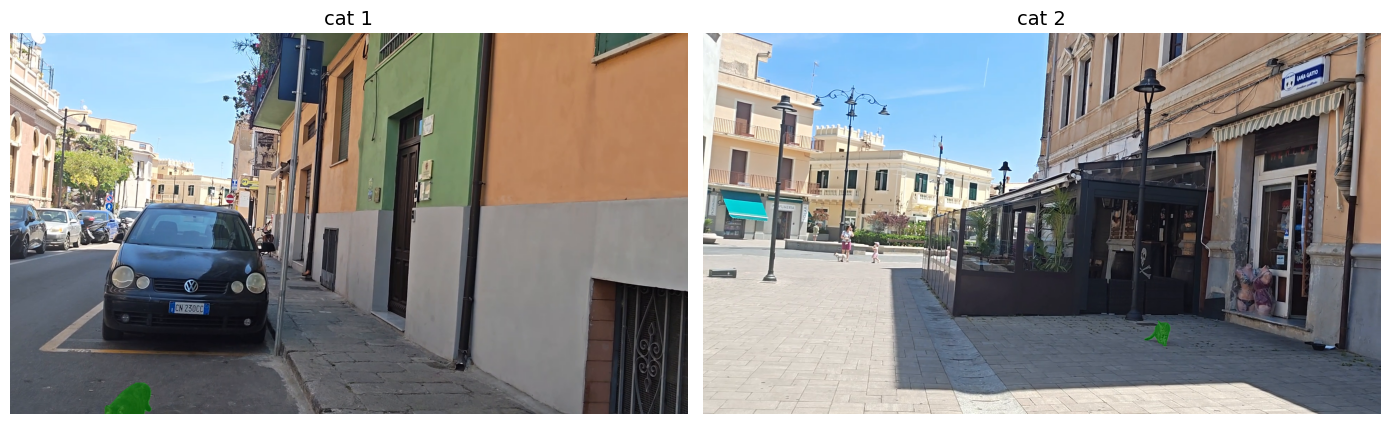

[{'subject': 'cat', 'start_s': 129, 'end_s': 144}]


In [28]:
if VID_TO_TEXT ==True:
        
    from A_Interactions import subject_selector
    subject_frame_range = subject_selector(
        video_path,
        detections,
        conf= 0.05,
        ) 
    print(subject_frame_range)
else:
    print("Cell disabled")

In [29]:
#YOLO - track moving subject footage
#works from video
from A_YOLO_seg import track_subject_masks_from_hints
if TRACKING == True:
    import sys
    sys.path.insert(0, str(project_root / "src"))

    from A_YOLO_seg import track_subject_masks

    results = track_subject_masks_from_hints(
        video_path=video_path,
        output_dir=str(yolo_masks_dir),
        detections=subject_frame_range,
        miss_threshold=100,
        conf=0.05
        )

    print(f"\n{len(results)} masks written to {yolo_masks_dir}")
    print(results)
else:
    print("Cell disabled")


Seeking subject start frame
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updating to [1088, 1920]
WARNING ⚠️ imgsz=[1080, 1920] must be multiple of max stride 32, updatin

In [30]:
from subject_analysis import analysis_2D
analysis = analysis_2D(video_path, yolo_masks_dir,api_key)

GPS_signal: yes
Subject_frames_present: [3854, 3855, 3856, 3858, 3859, 3860, 3861, 3863, 3864, 3865, 3866, 3867, 3868, 3869, 3871, 3872, 3873, 3874, 3875, 3876, 3877, 3878, 3879, 3880, 3881, 3882, 3883, 3884, 3886, 3887, 3888, 3889, 3890, 3891, 3892, 3893, 3894, 3895, 3896, 3897, 3898, 3899, 3911, 3912, 3914, 3915, 3916, 3918, 3919, 3920, 3921, 3924, 3925, 3926, 3927, 3931, 3933, 3934, 3935, 3936, 3937, 3939, 3941, 3942, 3943, 3944, 3945, 3946, 3948, 3950, 3951, 3954, 3955, 3956, 3957, 3958, 3959, 3961, 3962, 3963, 3964, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974, 3975, 3976, 3977, 3978, 3979, 3980, 3981, 3982, 3983, 3984, 3985, 3986, 3987, 3988, 3989, 3990, 3991, 3992, 3993, 3994, 3995, 3996, 3997, 3998, 3999, 4000, 4001, 4002, 4003, 4004, 4005, 4006, 4007, 4008, 4009, 4010, 4011, 4012, 4013, 4014, 4015, 4016, 4017, 4018, 4019, 4021, 4022, 4023, 4024, 4025, 4026, 4027, 4029, 4030, 4031, 4032, 4033, 4034, 4035, 4036, 4037, 4038, 4039, 4040, 4041, 4042, 4043, 4044, 4048, 4049,

In [31]:

#temp just to make this gel - it's for all of the cat images
print(min(analysis['Subject_frames_present']))
print(max(analysis['Subject_frames_present']))
start_3D_recon = min(analysis['Subject_frames_present'])
end_3D_recon = max(analysis['Subject_frames_present'])                 



3854
4404


In [49]:
#FRAME SELECTION - Frame selection to make the cam poses
CUT3R_size = (512,288) # resolution
if RECON_CAM_POSES == True and FRAME_SELECTION == True:
    # Parameters
    fps = 30.07
    interval     = 25/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
    res          =   CUT3R_size # resolution

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_cam_poses),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        start_frame  = start_3D_recon,
        end_frame    = end_3D_recon
    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

Cell disabled


In [32]:
#FRAMES FOR RECON SELECTION - Frame selection to make the recon

if RECON_3D == True and FRAME_SELECTION== True:
    # Parameters
    fps = 30.07
    interval     = 1/fps      # seconds between samples - expressed as frames to skip, per second(frame rate)
    window       = 15     # search window for sharpness
    min_sharp    = 0.0    # raise this after inspecting selection_log.json
    

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from Two2D.B_video_processing import image_sequencer

    results = image_sequencer(
        #video_path    = str(video_path),
        video_path = str(video_path),
        output_dir    = str(frames_for_recon),
        #res           = res,
        interval_sec  = interval,
        search_window = window,
        min_sharpness = min_sharp,
        #start_frame  = start_3D_recon,
        #end_frame    = end_3D_recon
        start_frame  = 3853,
        end_frame    = 4100

    )

    print(f"\n{len(results)} frames written to {frames_for_recon}")
else:
    print("Cell disabled")

Window  : clamped from ±15 to ±1 (half interval)
Video   : VID_20260530_113822990.mp4
          30.1 fps · 9675 frames · 321.8s
Range   : frames 3853-4100 (247 frames)
Sampling: every 1 frames (0.03325573661456601s) → 247 candidates
Window  : ±1 frames  |  scoring at 25% resolution


Pass 1: scoring: 100%|██████████| 247/247 [00:01<00:00, 144.62fr/s]


Selected: 247 frames  (2 shifted from sample point, 0 skipped below threshold)


Pass 3: writing: 100%|██████████| 247/247 [00:07<00:00, 31.51fr/s]

Log     : /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/cat_04/selection_log.json
Sharpness (at 25% res): min 1714 · mean 2557 · max 3817

2 frames written to /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/020_frames_for_recon/cat_04


In [51]:
#CUT3R basic implementation - copy past into command line

#cd c:\Users\djbar\Documents\MScPROJECT_LOCAL\Models\CUT3R
#python demo.py --model_path src/cut3r_512_dpt_4_64.pth --seq_path examples/001 --size 512 --vis_threshold 1.5 --output_dir tmp 

In [52]:
# Cell — CUT3R reconstruction 

if CUT3R_RECON == True and RECON_3D == True:
    import importlib, sys, traceback
    sys.path.insert(0, str(project_root / "src"))

    import D_cut3r_recon; importlib.reload(D_cut3r_recon)
    from D_cut3r_recon import run_cut3r
    import torch, gc
    gc.collect()
    torch.cuda.empty_cache()


    try:
        run_cut3r(
            frames_dir       = frames_for_recon,
            output_dir       = CUT3R_output_dir ,
            ckpt_path        = project_root / "Models" / "CUT3R" / "src" / "cut3r_512_dpt_4_64.pth",
            render_3rdperson = True,
            back_dist        = 0.5,
            up_dist          = 0.3,
            revisit          = True,
            conf_threshold   = 1.5,
        )
    except Exception:
        traceback.print_exc()
else:
    print("Cell disabled")

/opt/conda/envs/Msc2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Loading model...
... loading model from /workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/cut3r_512_dpt_4_64.pth
instantiating : ARCroco3DStereo(ARCroco3DStereoConfig(freeze='encoder',state_size=768,state_pe='2d',pos_embed='RoPE100',rgb_head=True,pose_head=True,patch_embed_cls='PatchEmbedDust3R',img_size=(512,512),head_type='dpt',output_mode='pts3d+pose',depth_mode=('exp',-inf,inf),conf_mode=('exp',1,inf),pose_mode=('exp',-inf,inf),enc_embed_dim=1024,enc_depth=24,enc_num_heads=16,dec_embed_dim=768,dec_depth=12,dec_num_heads=12,landscape_only=False))
<All keys matched successfully>
45 frames  →  /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_100_3


CUT3R:   0%|          | 0/45 [00:00<?, ?it/s]/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/heads/dpt_head.py:217: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/heads/dpt_head.py:226: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/workspaces/MScPROJECT_LOCAL/Models/CUT3R/src/dust3r/inference.py:254: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
CUT3R: 100%|██████████| 45/45 [00:32<00:00,  1.39it/s]


Pass 2 (revisiting): re-processing all frames with frozen final state...


revisit: 100%|██████████| 45/45 [00:47<00:00,  1.05s/it]


Revisit pass done. 45 frames in 0.8 min  (1.05 s/frame)
State saved → /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_100_3/cut3r_state.pt
Done. 45 frames in 1.3 min  (1.77 s/frame)
Output: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_CUT3R_output/cat_100_3


In [53]:
#camera assesment CUT3R
'''
if CUT3R_RECON == True:
    data = np.load(r"F:\MScPROJECT_LOCAL\Data\01_walk\035_CUT3R_output\24\camera\000100.npz")
    data["pose"]        # 4×4 camera-to-world
    #data["intrinsics"]  # 3×3 K matrix
else:
    print("Cell disabled")
    '''

'\nif CUT3R_RECON == True:\n    data = np.load(r"F:\\MScPROJECT_LOCAL\\Data\x01_walk\x1d_CUT3R_output\x14\\camera\x00100.npz")\n    data["pose"]        # 4×4 camera-to-world\n    #data["intrinsics"]  # 3×3 K matrix\nelse:\n    print("Cell disabled")\n    '

In [54]:
# Cell — MegaSaM reconstruction (mono-depth -> camera tracking -> CVD optimisation)
# requires the `mega_sam` conda env (Linux devcontainer only, see
# Models/mega-sam/LINUX_SETUP_CHANGELOG.md) — not available if running this
# notebook natively on Windows.
if MEGA_SAM_RECON == True and RECON_3D == True:
    '''this will replace CUT3R probably'''
    import importlib, sys, traceback
    sys.path.insert(0, str(project_root / "src"))

    import B_megasam_recon; importlib.reload(B_megasam_recon)
    from B_megasam_recon import run_megasam

    mega_sam_dir = project_root / "Models" / "mega-sam"

    try:
        megasam_npz = run_megasam(
            frames_dir   = frames_for_recon,
            output_dir   = case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full",
            mega_sam_dir = mega_sam_dir,
            scene_name   = case_name,
        )
    except Exception:
        traceback.print_exc()
else:
    print("Cell disabled")

Cell disabled


In [55]:
# Cell — MegaSaM visualisation
if MEGA_SAM_RECON == True and RECON_3D == True:
    import importlib, sys
    sys.path.insert(0, str(project_root / "src"))

    import B_megasam_vis; importlib.reload(B_megasam_vis)
    from B_megasam_vis import visualise_megasam

    visualise_megasam(megasam_npz)
else:
    print("Cell disabled")

Cell disabled


In [56]:
# Cell — VGGT reconstruction
if VGGT_RECON == True and RECON_3D == True:
    import sys
    import argparse
    sys.path.insert(0, str(project_root / "Models" / "VGGT"/ "vggt"))

    from demo_colmap import demo_fn

    recon_out  = case_dir / "034_VGGT_output" 
    max_frames = 55

    args = argparse.Namespace(
        scene_dir        = str(case_dir),
    
        image_dir        = str(frames_for_recon),
        output_dir       = str(recon_out),
        max_frames       = max_frames,
        load_resolution  = 518,
        seed             = 42,
        use_ba           = False,
        max_reproj_error = 8.0,
        shared_camera    = False,
        camera_type      = "SIMPLE_PINHOLE",
        vis_thresh       = 0.2,
        query_frame_num  = 8,
        max_query_pts    = 4096,
        fine_tracking    = True,
        conf_thres_value = 5.0,
    )

    demo_fn(args)
else:
    print("Cell disabled")

Cell disabled


In [ ]:
#VGGT OMEGA (sharded)
# Cell — VGGT-Omega reconstruction across multiple GPUs
if VGGT_O_RECON == True and RECON_3D == True and MULTI_PART_RECON == False:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

    

45 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 45 frames at 512px across 4 GPUs...
Aggregator done in 315.2s
Predicting camera poses...
Camera head done in 0.1s
Predicting depth maps...
Depth head done in 0.9s
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_100_3/predictions.npz
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_100_3/predictions.glb


In [7]:
#VGGT OMEGA (sharded) BATCH
# Cell — VGGT-Omega reconstruction across multiple GPUs - run a long sequence thorugh the batch processor.
#it sends in batches of 100 with an overlap of 1 frame for later alignment
if VGGT_O_RECON == True and RECON_3D == True and MULTI_PART_RECON == True:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards_batched

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards_batched(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 512,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")

    

VGGT_O will run 3 batches of up to 100 frames (245 frames total)
[1/3] frames 0:100
100 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 100 frames at 512px across 4 GPUs...


RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [58]:
# Cell — CUT3R visualisation
if CUT3R_RECON == True and RECON_3D == True:
        
    import importlib, sys
    sys.path.insert(0, str(project_root / "src"))

    import D_cut3r_vis; importlib.reload(D_cut3r_vis)
    from D_cut3r_vis import visualise_cut3r
    visualisation_dir = case_dir   /  VGGT_O_output_dir
    visualisation_dir = case_dir   /  CUT3R_output_dir
    visualise_cut3r(visualisation_dir)


Found 45 PLY files


╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

In [59]:
#temp for already solved 
RECON_CAM_POSES = True

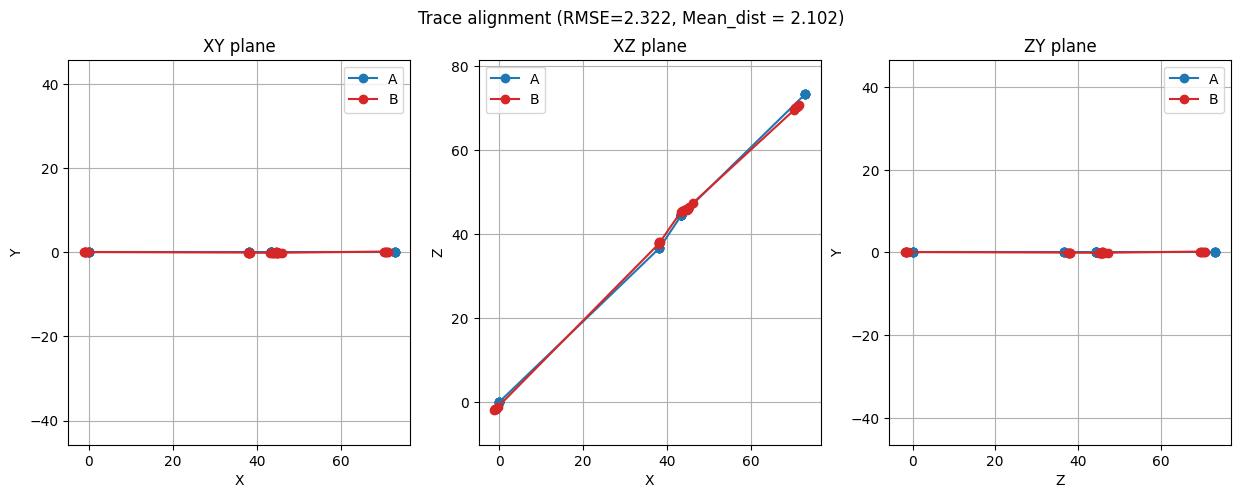

In [11]:
#convert CAMERA POSES from model-world-space into real-world-space (RS formatted at the moment)
if RECON_CAM_POSES == True and VGGT_O_RECON ==True:
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R, s, t, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)
else:
    print("Cell disabled")

In [7]:
#LOAD VGGT_O recon for further processing
from E_post_recon_processing import Reconstruction
recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_100_all/predictions.npz'

metricification
Subject VGGT-O → real-world: 23 pairs, RMSE = 0.1374 m
Subject VGGT-O → real-world: 38 pairs, RMSE = 0.1231 m
Subject VGGT-O → real-world: 44 pairs, RMSE = 0.0881 m
plys
ply 2
ply 3


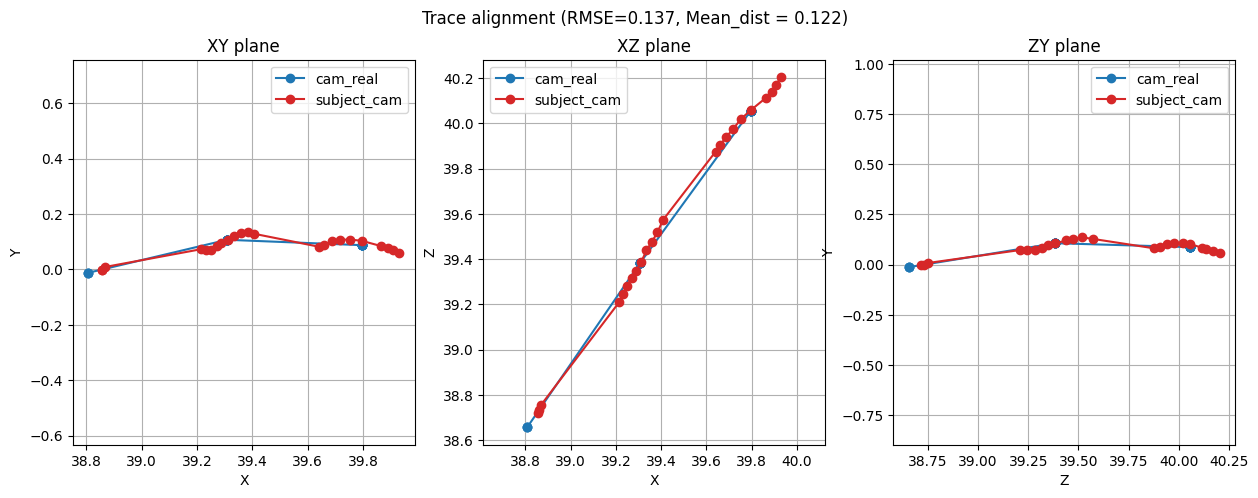

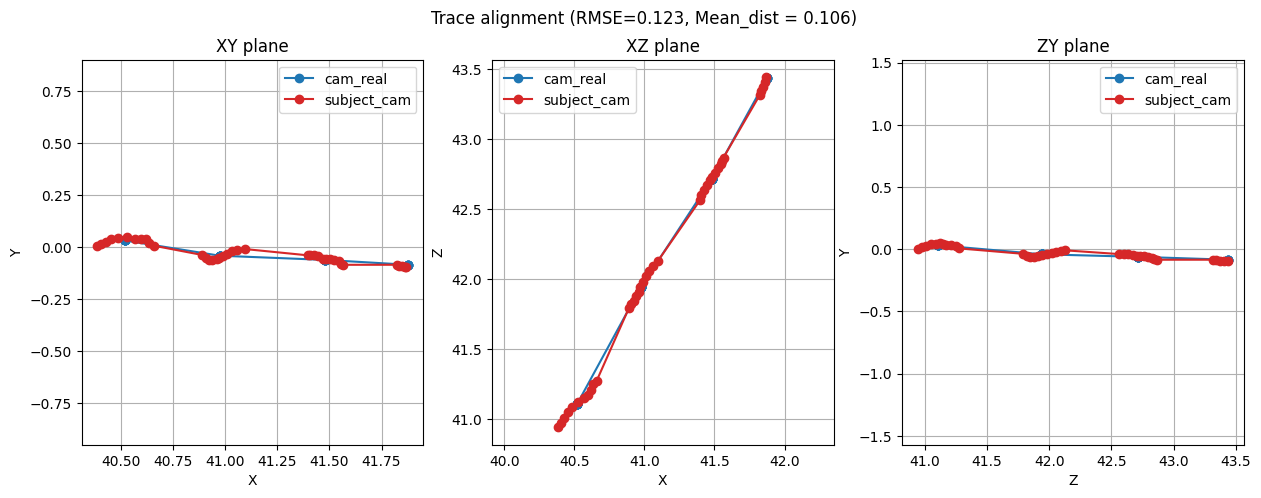

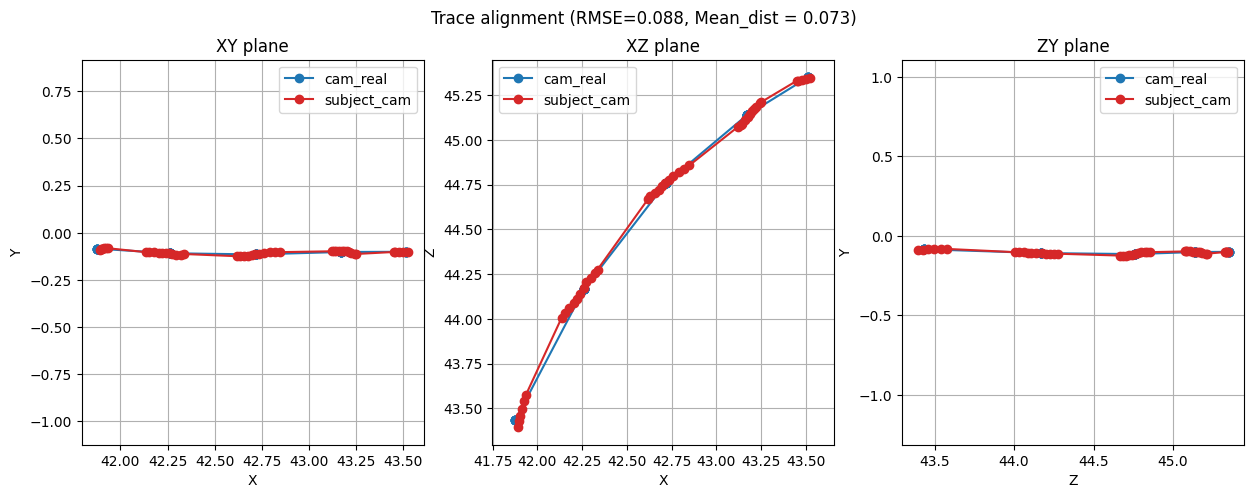

In [ ]:
#MULTI
#processes spatial information about the subject - for report and generates the data needed to map the subject
from E_post_recon_processing import Reconstruction
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
if VGGT_O_RECON == True:
    if MULTI_PART_RECON == True:
        recon_0 = Reconstruction.load(case_dir / "020_frames_for_recon" / "cat_03_45",    case_dir / "035_VGGT_O_output" / "cat_03_45" /"predictions.npz",    FRAME_NAME_FMT)
        recon_1 = Reconstruction.load(case_dir / "020_frames_for_recon" / "cat_03_100_2",   case_dir / "035_VGGT_O_output" / "cat_03_100_2"/"predictions.npz",   FRAME_NAME_FMT)
        recon_2 = Reconstruction.load(case_dir / "020_frames_for_recon" / "cat_03_100", case_dir / "035_VGGT_O_output" / "cat_03_100"/"predictions.npz", FRAME_NAME_FMT)
        multi = True
        print("metricification")
        from subject_analysis import subject_to_metric_and_gps_space
        yolo_masks_dir = case_dir   / "015_YOLO" / "cat_100" #HARDCODED!!!
        sub_latlon_0, sub_pos_0, sub_pos_real_dict_0, R_cr_0, s_cr_0, t_cr_0 = subject_to_metric_and_gps_space(
            recon_0,
            masks_dir=str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            cam_poses_realworld_dict=cam_poses_realworld_dict,
        )
        #lose this
        sub_latlon_1, sub_pos_1, sub_pos_real_dict_1, R_cr_1, s_cr_1, t_cr_1 = subject_to_metric_and_gps_space(
            recon_1,
            masks_dir=str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            cam_poses_realworld_dict=cam_poses_realworld_dict,
        )
        #lose this
        sub_latlon_2, sub_pos_2, sub_pos_real_dict_2, R_cr_2, s_cr_2, t_cr_2 = subject_to_metric_and_gps_space(
            recon_2,
            masks_dir=str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            cam_poses_realworld_dict=cam_poses_realworld_dict,
        )
        print("plys")

        #need to do   
        recon 1frame 0 vs recon0 frame 100  using recon0's new scale  - unemaya
        apply to all frames - need to do the cams
        recon 2 vs recon1 - image
        apply to all frames

        #now all are aligned


        

        #can lkose the centre to cam 0?

        #MAKE PLYS of VGGT_O
        #turn VGGT_O output into cam0 space then scale it to metres and make relative to the campaths solve, then transform teh orgin somewere more user friendl
        centre = recon_0.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_cr_0, t=t_cr_0, s=s_cr_0, multi=multi)
        print("ply 2")
        centre = recon_1.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" ,R=R_cr_1, t=t_cr_1, s=s_cr_1, multi=multi, centre_to_cam00=centre)
        print("ply 3")
        centre = recon_2.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" ,R=R_cr_2, t=t_cr_2, s=s_cr_2, multi=multi, centre_to_cam00=centre)
else:
    print("Cell disabled")


Subject VGGT-O → real-world: 23 pairs, RMSE = 0.1374 m


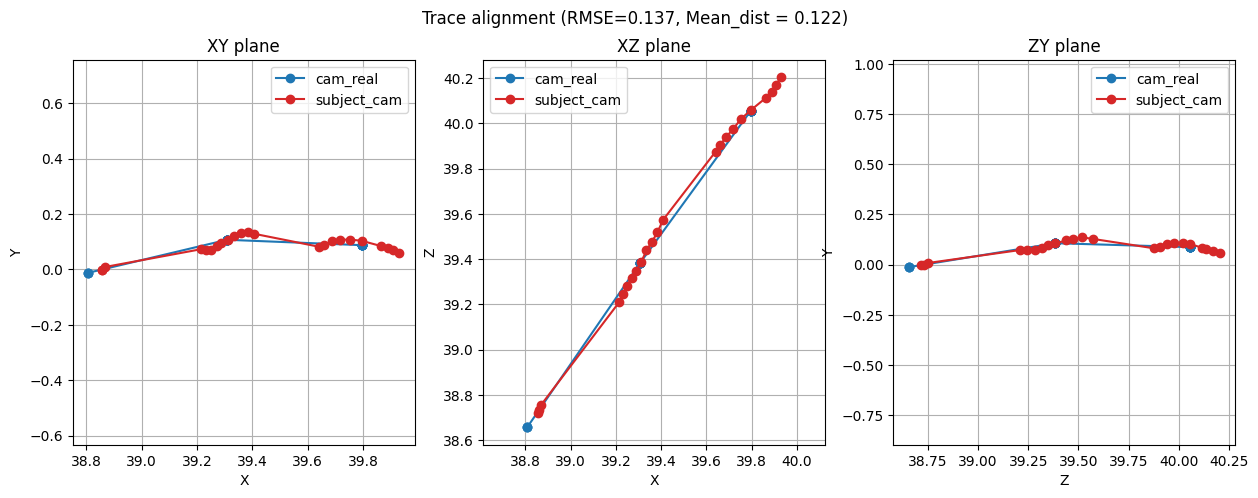

In [68]:
#processes spatial information about the subject - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in
if RECON_CAM_POSES == True and VGGT_O_RECON ==True:
    if MULTI_PART_RECON == False:
        from subject_analysis import subject_to_metric_and_gps_space
        sub_latlon, sub_pos, sub_pos_real_dict, R_cr, s_cr, t_cr  = subject_to_metric_and_gps_space(
            recon,
            masks_dir        = str(yolo_masks_dir),
            lat_0=lat_0, lon_0=lon_0,
            cam_poses_realworld_dict = cam_poses_realworld_dict,
            )    

        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
        recon.VGGT_O_preds_to_ply_export(R = R_cr, t= t_cr, s=s_cr)   # writes to predictions_path.parent / "ply"
        print(predictions_path)
else:
     print("Cell disabled")

/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_100_3/predictions.npz


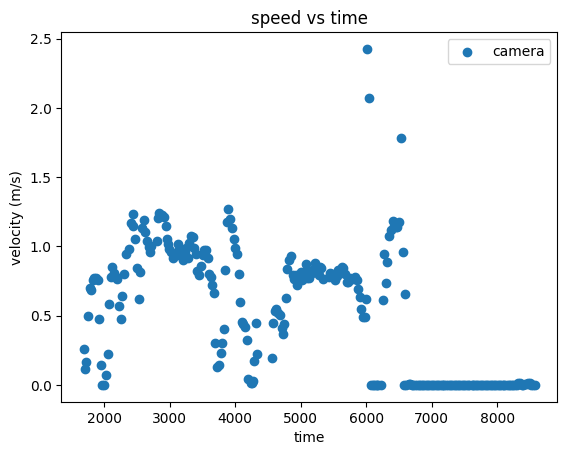

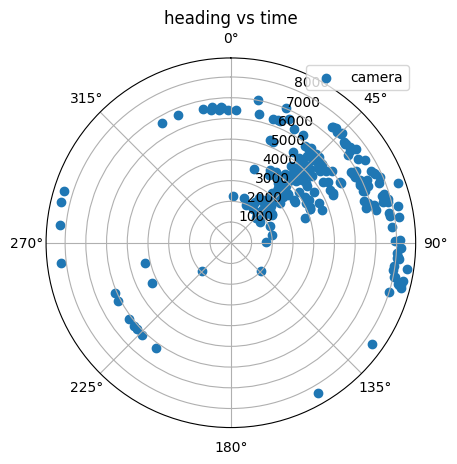

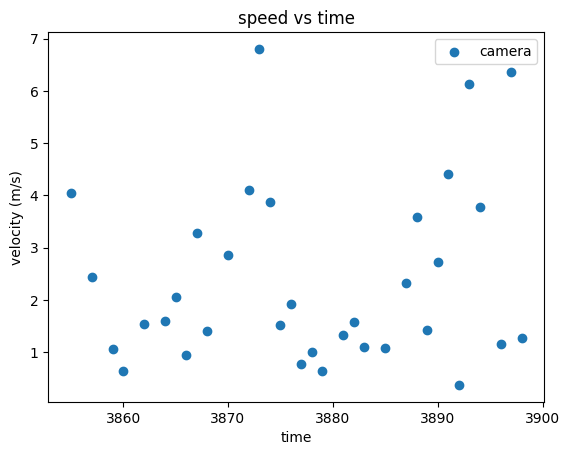

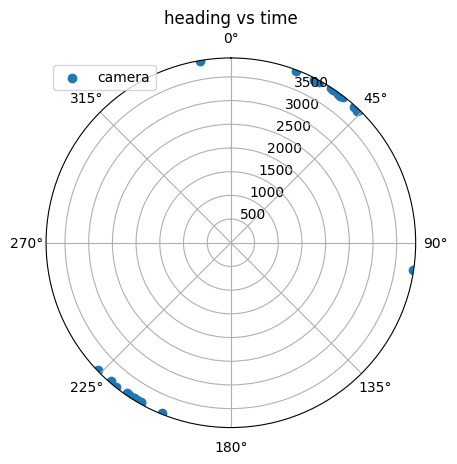

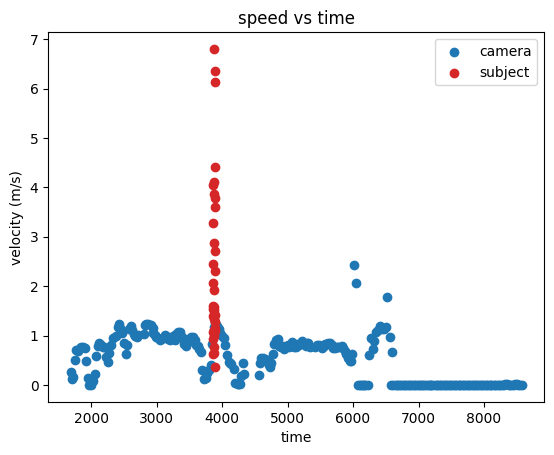

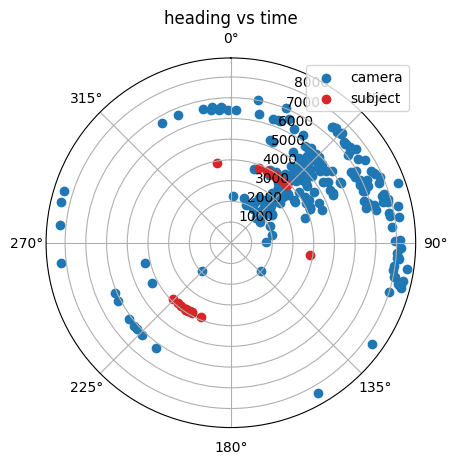

In [70]:
##Graphing and analysis of camera  TEMPORARY in here
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
fps = 30.07 #temp!
metrics = speed_direction(cam_poses_realworld_dict, fps)
sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )

In [71]:
#make animated map can do svg, giof or mp4. SVG is default
if GOOGLE_MAP ==True:
    import importlib, R_map_animator

    R_map_animator.main(
        traces=[
            {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
            {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
        ],
        api_key     = api_key,
        gif = True,
        mp4 = None
        

    )
else:
    print("Cell disabled")

Cell disabled


In [18]:
if PROJECTION_MAP == True:
    #2D projection mapping of subject to a selected view
    from E_post_recon_processing import Reconstruction
    from P_projection_mapping import projection_mapping_sequence

    subject_recon = Reconstruction.load(frames_for_recon, predictions_path, FRAME_NAME_FMT)

    subject_positions = projection_mapping_sequence(
        
        recon         = subject_recon,
        main_idx      = 3900,
        extra_indices = range (3853,4100),
          #other syntax  [400,4027, 4052, 4065],
        masks_dir     = str(yolo_masks_dir),
       
       )
else:
    print("Cell disabled")

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_100_all/predictions.npz'

In [21]:
from Rendering.U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if VGGT_O_RECON ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_all/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [91]:

#cutr point cloud render
if CUT3R_RECON ==True:  
    visualisation_dir = case_dir   /  CUT3R_output_dir 
    model = "CUT3R"
    ply_dir = visualisation_dir / "ply"
    basic_point_cloud_render(
        ply_dir, model     )
    # report metric name = render name, one row per output asset (path relative to
   



/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_CUT3R


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [92]:
#get times of day into the report
from V_CSV_report import attach_times_of_day
report = attach_times_of_day(video_path, 30.07)


In [93]:
if MAKE_MOVIE ==True:
  #MAKING A MOVIE
  '''This controls M_scoring. It's independent of scene recon, so could be placed anywhere'''
  '''bring in M_scoring_controls'''
  from C_video_editor import video_overlay_edit
  movie =video_overlay_edit(video_path, 
                            3500, 
                            4600, 
                            yolo_masks_dir, 
                            3777, 4557,
                            handles=2, 
                          color=(0, 200, 0), 
                          alpha=0.4) 

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

KeyboardInterrupt: 

In [ ]:
# Cell — Populate PowerPoint from CSV
import sys
import importlib
sys.path.insert(0, str(project_root / "src"))

import W_populate_pptx
importlib.reload(W_populate_pptx)
from W_populate_pptx import populate



report_template = project_root / "src" / "Powerpoint" / f"{ppt_template}.pptx"
ppt_assets   = case_dir / "090_Assets"
ppt_csv      = ppt_assets / f"{case_name}.csv"
ppt_output   = case_dir / "100_Powerpoint" / f"{case_name}.pptx"


populate(str(report_template))


  'Title' -> shape 'Title'
  'place' -> shape 'place'
  'overlay_mp4' -> shape 'overlay_mp4'
  'speed_graph' -> shape 'speed_graph'
  'projection_mp4' -> shape 'projection_mp4'
  'point_cloud_render_VGGT_O_gif' -> shape 'point_cloud_render_VGGT_O_gif'
  'point_cloud_render_CUT3R_gif' -> shape 'point_cloud_render_CUT3R_gif'
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)
  Removing empty slide (nothing matched from report)

Saved: /workspaces/knuckles_drive/Data/07_Tropea_cafe/100_Powerpoint/07_Tropea_cafe_cat_100_2.pptx


In [ ]:
import pycolmap, sys
print(pycolmap.__version__)
print(sys.executable)


4.0.4
/opt/conda/envs/Msc2/bin/python
